# Bayesian Framework for Forecasting External‑Drive Failures and Optimising Economic Risk

This notebook implements a Monte‑Carlo and multi‑objective optimisation pipeline that **maximises expected profit** while **constraining downside risk** (CVaR) for external‑drive procurement.

## Notebook Outline
1. Imports & global settings  
2. Data loading / synthetic fallback  
3. Failure‑rate estimation per model  
4. Stochastic input generators  
5. Profit model  
6. Monte‑Carlo simulation & risk metrics  
7. Multi‑objective optimisation (`μ` vs. `CVaRα`)  
8. Pareto‑front visualisation  
9. Policy recommendation

In [3]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import numpy.random as npr

try:
    import pymoo
    from pymoo.core.problem import Problem
    from pymoo.algorithms.moo.nsga2 import NSGA2
    from pymoo.optimize import minimize
except ImportError:
    pymoo = None
    print("⚠️  pymoo not found – optimisation step will be skipped.")

try:
    import scipy.stats as st
except ImportError:
    st = None
    print("⚠️  scipy not found – falling back to simple normal draws.")

import matplotlib.pyplot as plt
%matplotlib inline

RANDOM_SEED = 42
npr.seed(RANDOM_SEED)


In [11]:
import pandas as pd
import glob
import os

path = '/Users/cobeq/Downloads/data_Q4_2024/*.csv' # use your path
all_files = glob.glob(path)

li = []

for filename in all_files:
    df = pd.read_csv(filename, index_col=None, header=0)
    li.append(df)

frame = pd.concat(li, axis=0, ignore_index=True)

/var/folders/8r/nncxr9rj3530t_n2qx479mv00000gn/T/ipykernel_97749/1473536513.py:11: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename, index_col=None, header=0)
/var/folders/8r/nncxr9rj3530t_n2qx479mv00000gn/T/ipykernel_97749/1473536513.py:11: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename, index_col=None, header=0)
/var/folders/8r/nncxr9rj3530t_n2qx479mv00000gn/T/ipykernel_97749/1473536513.py:11: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename, index_col=None, header=0)
/var/folders/8r/nncxr9rj3530t_n2qx479mv00000gn/T/ipykernel_97749/1473536513.py:11: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename, index_col=None, header=0)
/var/folders/8r/nncxr9rj3530t_n2qx479mv00000gn/T

In [12]:
glob.glob(path)

['/Users/cobeq/Downloads/data_Q4_2024/2024-11-02.csv',
 '/Users/cobeq/Downloads/data_Q4_2024/2024-11-16.csv',
 '/Users/cobeq/Downloads/data_Q4_2024/2024-11-17.csv',
 '/Users/cobeq/Downloads/data_Q4_2024/2024-11-03.csv',
 '/Users/cobeq/Downloads/data_Q4_2024/2024-11-29.csv',
 '/Users/cobeq/Downloads/data_Q4_2024/2024-11-15.csv',
 '/Users/cobeq/Downloads/data_Q4_2024/2024-11-01.csv',
 '/Users/cobeq/Downloads/data_Q4_2024/2024-11-14.csv',
 '/Users/cobeq/Downloads/data_Q4_2024/2024-11-28.csv',
 '/Users/cobeq/Downloads/data_Q4_2024/2024-11-10.csv',
 '/Users/cobeq/Downloads/data_Q4_2024/2024-11-04.csv',
 '/Users/cobeq/Downloads/data_Q4_2024/2024-11-05.csv',
 '/Users/cobeq/Downloads/data_Q4_2024/2024-11-11.csv',
 '/Users/cobeq/Downloads/data_Q4_2024/2024-11-07.csv',
 '/Users/cobeq/Downloads/data_Q4_2024/2024-11-13.csv',
 '/Users/cobeq/Downloads/data_Q4_2024/2024-11-12.csv',
 '/Users/cobeq/Downloads/data_Q4_2024/2024-11-06.csv',
 '/Users/cobeq/Downloads/data_Q4_2024/2024-12-30.csv',
 '/Users/c

In [14]:
models = sorted(df["model"].unique())
print("Active models:", models)
print("Number of models:", len(models))

Active models: ['CT250MX500SSD1', 'DELLBOSS VD', 'HGST HDS724040ALE640', 'HGST HMS5C4040ALE640', 'HGST HMS5C4040BLE640', 'HGST HUH721010ALE600', 'HGST HUH721212ALE600', 'HGST HUH721212ALE604', 'HGST HUH721212ALN604', 'HGST HUH728080ALE600', 'HGST HUH728080ALE604', 'HGST HUS726040ALE610', 'HGST HUS728T8TALE6L4', 'MTFDDAV240TCB', 'MTFDDAV480TCB', 'Micron 5300 MTFDDAK480TDS', 'SSDSCKKB240GZR', 'ST10000NM001G', 'ST10000NM0086', 'ST1000LM024 HN', 'ST12000NM0007', 'ST12000NM0008', 'ST12000NM000J', 'ST12000NM001G', 'ST12000NM003G', 'ST12000NM0117', 'ST14000NM000J', 'ST14000NM0018', 'ST14000NM001G', 'ST14000NM002J', 'ST14000NM0138', 'ST16000NM000J', 'ST16000NM001G', 'ST16000NM002J', 'ST16000NM005G', 'ST18000NM000J', 'ST4000DM000', 'ST500LM012 HN', 'ST500LM021', 'ST500LM030', 'ST8000DM002', 'ST8000DM005', 'ST8000NM000A', 'ST8000NM0055', 'Samsung SSD 850 EVO 1TB', 'Samsung SSD 860 PRO 2TB', 'Seagate BarraCuda 120 SSD ZA250CM10003', 'Seagate BarraCuda 120 SSD ZA500CM10003', 'Seagate BarraCuda SSD

In [43]:

# ----- Global simulation settings -----
ALPHA      = 0.05   # CVaR tail fraction
N_SIM      = 5_000  # Monte‑Carlo iterations
MAX_UNITS  = 1_000  # Upper bound per model in optimisation

# Economic assumptions (example values – adjust!)
REVENUE_PER_DISK    = 1_000
REPLACEMENT_PENALTY =   300
COST_MEAN = {
    model: REPLACEMENT_PENALTY + len(model.split()) * 100
    for model in models
}
COST_STD = {k: v*0.05 for k, v in COST_MEAN.items()}  # 5 % stdev

# Predictive‑model accuracy
ACCURACY = 0.95


In [44]:

def estimate_failure_rate(frame: pd.DataFrame) -> pd.DataFrame:
    """Estimate annualised failure rate per model."""
    daily = frame.groupby("model")["failure"].agg(["mean", "count"])
    daily["annual_rate"] = 1 - (1 - daily["mean"]) ** 365
    return daily

failure_stats = estimate_failure_rate(df)
display(failure_stats)

def get_failure_dist(model: str):
    mu = failure_stats.loc[model, "annual_rate"]
    sigma = max(mu * 0.1, 1e-4)  # 10 % coefficient of variation
    return {"loc": mu, "scale": sigma}


,mean,count,annual_rate
model,,,
CT250MX500SSD1,0.000000,692,0.000000
DELLBOSS VD,0.000000,431,0.000000
HGST HDS724040ALE640,0.000000,1,0.000000
HGST HMS5C4040ALE640,0.000000,277,0.000000
HGST HMS5C4040BLE640,0.000000,4983,0.000000
...,...,...,...
WDC WUH721414ALE6L4,0.000117,8525,0.041914
WDC WUH721816ALE6L0,0.000000,3020,0.000000
WDC WUH721816ALE6L4,0.000000,26395,0.000000


In [46]:

def sample_failure_rates():
    """Draw one annual failure probability per model."""
    return {m: max(0.0, npr.normal(**get_failure_dist(m))) for m in models}

def sample_unit_cost(model: str):
    return max(0.0, npr.normal(COST_MEAN[model], COST_STD[model]))


In [47]:

def profit_once(X, failure_draws):
    """
    Compute profit for a single Monte-Carlo draw.

    Parameters
    ----------
    X : array-like[int]
        Units procured per model (same order as `models`).
    failure_draws : dict
        Annual failure probability for each model.
    """
    total_profit = 0.0
    for i, model in enumerate(models):
        units = int(X[i])
        if units <= 0:
            continue

        purchase_cost = sample_unit_cost(model)
        failure_rate  = failure_draws[model]

        # Inject predictive-model misclassification
        if npr.rand() > ACCURACY:
            failure_rate = min(1.0, failure_rate * 2)

        failures = npr.binomial(units, failure_rate)
        revenue  = REVENUE_PER_DISK * units
        total_cost = purchase_cost * units + REPLACEMENT_PENALTY * failures
        total_profit += revenue - total_cost

    return total_profit


In [48]:

def simulate_profit(X, n_sim=N_SIM):
    samples = np.empty(n_sim)
    for i in range(n_sim):
        samples[i] = profit_once(X, sample_failure_rates())
    return samples

def mean_and_cvar(samples, alpha=ALPHA):
    mu = samples.mean()
    sorted_samples = np.sort(samples)
    n_tail = max(1, int(alpha * len(sorted_samples)))
    cvar = sorted_samples[:n_tail].mean()
    return mu, cvar


In [49]:

# Quick sanity check on an arbitrary procurement vector
X_test = np.full(len(models), 100)
samples = simulate_profit(X_test, n_sim=1_000)
mu_test, cvar_test = mean_and_cvar(samples)
print(f"Test vector {X_test.tolist()} → μ = {mu_test:,.0f}, CVaR{ALPHA} = {cvar_test:,.0f}")


Test vector [100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100] → μ = 3,721,556, CVaR0.05 = 3,673,729


In [50]:
from pymoo.core.problem import Problem


class ProcurementProblem(Problem):
    def __init__(self):
        super().__init__(
            n_var=len(models),      # по одному решаемому X на модель
            n_obj=2,               # (-μ,  CVaR)
            xl=np.zeros(len(models)),
            xu=np.full(len(models), MAX_UNITS),
        )

    def _evaluate(self, X, out, *args, **kwargs):
        """
        X : ndarray, shape (pop_size, n_var)
        out["F"] : ndarray, shape (pop_size, n_obj)
        """
        pop = X.shape[0]
        F = np.empty((pop, 2))
        for i in range(pop):
            Xi = X[i].astype(int)
            samples = simulate_profit(Xi)
            mu, cvar = mean_and_cvar(samples)
            F[i, 0] = -mu   # pymoo минимизирует
            F[i, 1] =  cvar
        out["F"] = F

algo = NSGA2(pop_size=32)
res = minimize(
    ProcurementProblem(),
    algo,
    ("n_gen", 10),  # increase for more thorough search
    seed=RANDOM_SEED,
    save_history=False,
    verbose=True,
)

pareto_X = res.X.astype(int)
pareto_F = res.F
print(f"Found {len(pareto_X)} Pareto-optimal points.")

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       32 |     31 |             - |             -
     2 |       64 |     32 |  0.1625368944 |         ideal
     3 |       96 |     32 |  0.0589236602 |         ideal
     4 |      128 |     32 |  0.0861586419 |         ideal
     5 |      160 |     32 |  0.0443362512 |         ideal
     6 |      192 |     32 |  0.1098142962 |         ideal
     7 |      224 |     32 |  0.0077851713 |             f
     8 |      256 |     32 |  0.0835178255 |         ideal
     9 |      288 |     32 |  0.0058688043 |             f
    10 |      320 |     32 |  0.0064792156 |             f
Found 32 Pareto-optimal points.


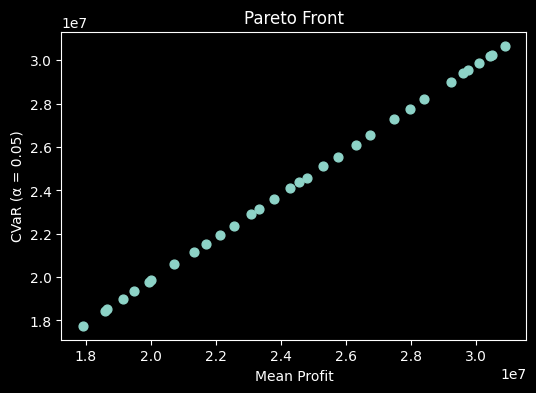

In [42]:

if pareto_F is not None:
    fig, ax = plt.subplots(figsize=(6,4))
    ax.scatter(-pareto_F[:,0], pareto_F[:,1], s=40)
    ax.set_xlabel("Mean Profit")
    ax.set_ylabel(f"CVaR (α = {ALPHA})")
    ax.set_title("Pareto Front")
    plt.show()
else:
    print("No Pareto front to display.")


In [39]:

if pareto_F is not None:
    idx = np.argmax((-pareto_F[:,0]) / pareto_F[:,1])
    best_X = pareto_X[idx]
    mu_best, cvar_best = -pareto_F[idx,0], pareto_F[idx,1]

    print("📌 Recommended procurement vector:")
    for m, units in zip(models, best_X):
        print(f"  • {m}: {units} units")
    print(f"\nExpected mean profit: {mu_best:,.0f}")
    print(f"CVaR{ALPHA}: {cvar_best:,.0f}")
else:
    print("Recommendation unavailable (optimisation skipped).")


📌 Recommended procurement vector:
  • CT250MX500SSD1: 181 units
  • DELLBOSS VD: 706 units
  • HGST HDS724040ALE640: 606 units
  • HGST HMS5C4040ALE640: 399 units
  • HGST HMS5C4040BLE640: 54 units
  • HGST HUH721010ALE600: 140 units
  • HGST HUH721212ALE600: 95 units
  • HGST HUH721212ALE604: 11 units
  • HGST HUH721212ALN604: 331 units
  • HGST HUH728080ALE600: 404 units
  • HGST HUH728080ALE604: 537 units
  • HGST HUS726040ALE610: 129 units
  • HGST HUS728T8TALE6L4: 366 units
  • MTFDDAV240TCB: 819 units
  • MTFDDAV480TCB: 737 units
  • Micron 5300 MTFDDAK480TDS: 362 units
  • SSDSCKKB240GZR: 477 units
  • ST10000NM001G: 675 units
  • ST10000NM0086: 138 units
  • ST1000LM024 HN: 175 units
  • ST12000NM0007: 498 units
  • ST12000NM0008: 110 units
  • ST12000NM000J: 182 units
  • ST12000NM001G: 362 units
  • ST12000NM003G: 48 units
  • ST12000NM0117: 918 units
  • ST14000NM000J: 847 units
  • ST14000NM0018: 672 units
  • ST14000NM001G: 199 units
  • ST14000NM002J: 569 units
  • ST1400